# Experiment – 7 : Logistic Regression

---

**Name:** Shruti Hore  

**PRN:** 24070126172  

---

**Title:** Implementation of Logistic Regression for Classification

---

**Aim:** To implement and understand the Logistic Regression algorithm for classification tasks and evaluate its performance on a given dataset.

---

**Objective:**
•	Understand the logistic regression classification mechanism.
•	Implement the logistic regression algorithm on a dataset for classification.
•	Evaluate the performance using relevant metrics such as accuracy, precision, recall, and F1-score.
•	Visualize the decision boundary of the logistic regression model.

---

**Problem statement**

Use the given dataset(s) to demonstrate the application of the Logistic Regression algorithm for classification. The task is to classify the data points into different classes based on the features and to understand how logistic regression models the probability of class membership using a sigmoid function.

---

# Logistic Regression

Logistic Regression is a supervised learning algorithm used for **binary classification**.  
It models the probability that an input belongs to a particular class using a sigmoid function.

It outputs probabilities in the range $[0,1]$ and applies a threshold (usually 0.5) for classification.

---

## Mathematical Formulation

### 1. Linear Model
$$
z = w^T x + b
$$

Where:
- $w$ = weight vector  
- $x$ = feature vector  
- $b$ = bias  

---

### 2. Sigmoid Function
$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Predicted probability:
$$
\hat{y} = \sigma(w^T x + b)
$$

---

### 3. Loss Function (Binary Cross-Entropy / Log Loss)
$$
J(w,b) = - \frac{1}{m} \sum_{i=1}^{m}
\left[
y^{(i)} \log(\hat{y}^{(i)}) +
(1 - y^{(i)}) \log(1 - \hat{y}^{(i)})
\right]
$$

Goal: Minimize $J(w,b)$ using Gradient Descent.

---

## Algorithm (Stepwise Procedure)

1. Initialize weights and bias.
2. Compute $z = w^T x + b$.
3. Apply sigmoid to get predictions.
4. Compute log loss.
5. Update parameters using gradient descent:
   $$
   w := w - \alpha \frac{\partial J}{\partial w}
   $$
6. Repeat until convergence.

---

## Importance in Classification

- Outputs probabilities (interpretable).
- Works well for linearly separable data.
- Computationally efficient.
- Less prone to overfitting with regularization.
- Forms the basis of many advanced classifiers.

---

## Applications

- Email spam detection  
- Medical diagnosis  
- Credit risk prediction  
- Customer churn prediction  
- Fraud detection  
- Sentiment analysis  

---

## Performance Metrics

### Confusion Matrix
$$
\begin{bmatrix}
TP & FN \\
FP & TN
\end{bmatrix}
$$

### Accuracy
$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

### Precision
$$
Precision = \frac{TP}{TP + FP}
$$


### Cross-Validation
Split data into $k$ folds, train on $k-1$, test on remaining fold, average results.

---

## Input and Output

### Input
- Dataset (features $X$, target $y$)
- User test input data

### Output
- Predicted class labels
- Predicted probabilities
- Evaluation metrics (Accuracy, Precision, Recall, F1-score)
- Visualizations (decision boundary, ROC curve, loss curve)

---

## Diagrams

### Sigmoid Curve
$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$




---

## Decision Boundary

For binary classification:
$$
w^T x + b = 0
$$

This represents a linear decision boundary.

---

## Impact of Hyperparameters

### Learning Rate ($\alpha$)
- Too large → Divergence
- Too small → Slow convergence

### Regularization

#### L1 (Lasso)
$$
J = J + \lambda \sum |w|
$$
- Produces sparse models

#### L2 (Ridge)
$$
J = J + \lambda \sum w^2
$$
- Prevents large weights

### Number of Iterations
- Too few → Underfitting
- Too many → May overfit (if no regularization)

---


# Import libaries and load dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             confusion_matrix)
from sklearn.linear_model import LogisticRegression


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/SEMESTER 4/LABS/SML-L/datasets/(7) insurance_data.csv')
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


0 -> bought insurance

1 -> has not bought insurance

Text(0, 0.5, 'Insurance')

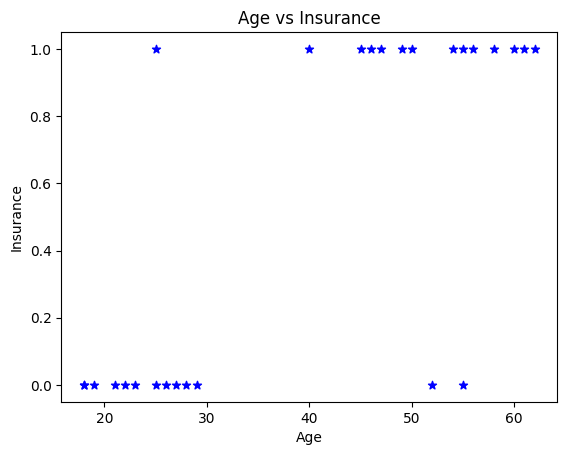

In [ ]:
plt.scatter(df.age,
            df.bought_insurance,
            marker='*',
            color='blue')
plt.title("Age vs Insurance")
plt.xlabel("Age")
plt.ylabel("Insurance")

# Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df[['age']],
                                                    df[['bought_insurance']],
                                                    train_size=0.75,
                                                    random_state=23)

In [ ]:
X_test

,age
18,19
21,26
4,46
3,52
17,58
16,25
14,49


In [ ]:
X_train

,age
23,45
10,18
0,22
15,55
5,56
11,28
2,47
1,25
26,23
20,21


In [ ]:
LR = LogisticRegression()

LR.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [ ]:
y_pred = LR.predict(X_test)

In [ ]:
#
LR.predict_proba(X_test)

array([[0.98272138, 0.01727862],
       [0.93760858, 0.06239142],
       [0.25108912, 0.74891088],
       [0.09677114, 0.90322886],
       [0.03310383, 0.96689617],
       [0.94784845, 0.05215155],
       [0.15933028, 0.84066972]])

In [ ]:
LR.score(X_test, y_test)

0.7142857142857143

In [ ]:
y_pred

array([0, 0, 1, 1, 1, 0, 1])

In [ ]:
acc = accuracy_score(y_test, y_pred) * 100
print(f"Logistics Regression model accuracy : {acc:.3f}%")

Logistics Regression model accuracy : 71.429%


LR.coef_ is the value of m &

LR.intercept_ is the value of b in y = mx + c equation


In [ ]:
LR.coef_

array([[0.19013584]])

In [ ]:
LR.intercept_

array([-7.65343678])

### Sigmoid Function

In [ ]:
import math
def sigmoid(x):
  return 1 / (1 + math.exp(-x))

In [ ]:
def pred_func(age):
  z = 0.1901 * age - 7.653
  y = sigmoid(z)
  return y

In [ ]:
pred_func(20)

0.020815952100419692

In [ ]:
pred_func(40)

0.4877524504324861

In [ ]:
pred_func(41)

0.5352165915020537

- person after the age of 40-41 will buy insurance
- below 0.5 -> will not buy (0)
- above 0.5 -> will buy (1)

# 2. Diabetes Dataset

In [ ]:
# load dataset
data = pd.read_csv('/content/drive/MyDrive/SEMESTER 4/LABS/SML-L/datasets/(7) diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### EDA on the dataset

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [ ]:
data.shape

(768, 9)

In [ ]:
data.nunique()

,0
Pregnancies,17
Glucose,136
BloodPressure,47
SkinThickness,51
Insulin,186
BMI,248
DiabetesPedigreeFunction,517
Age,52
Outcome,2


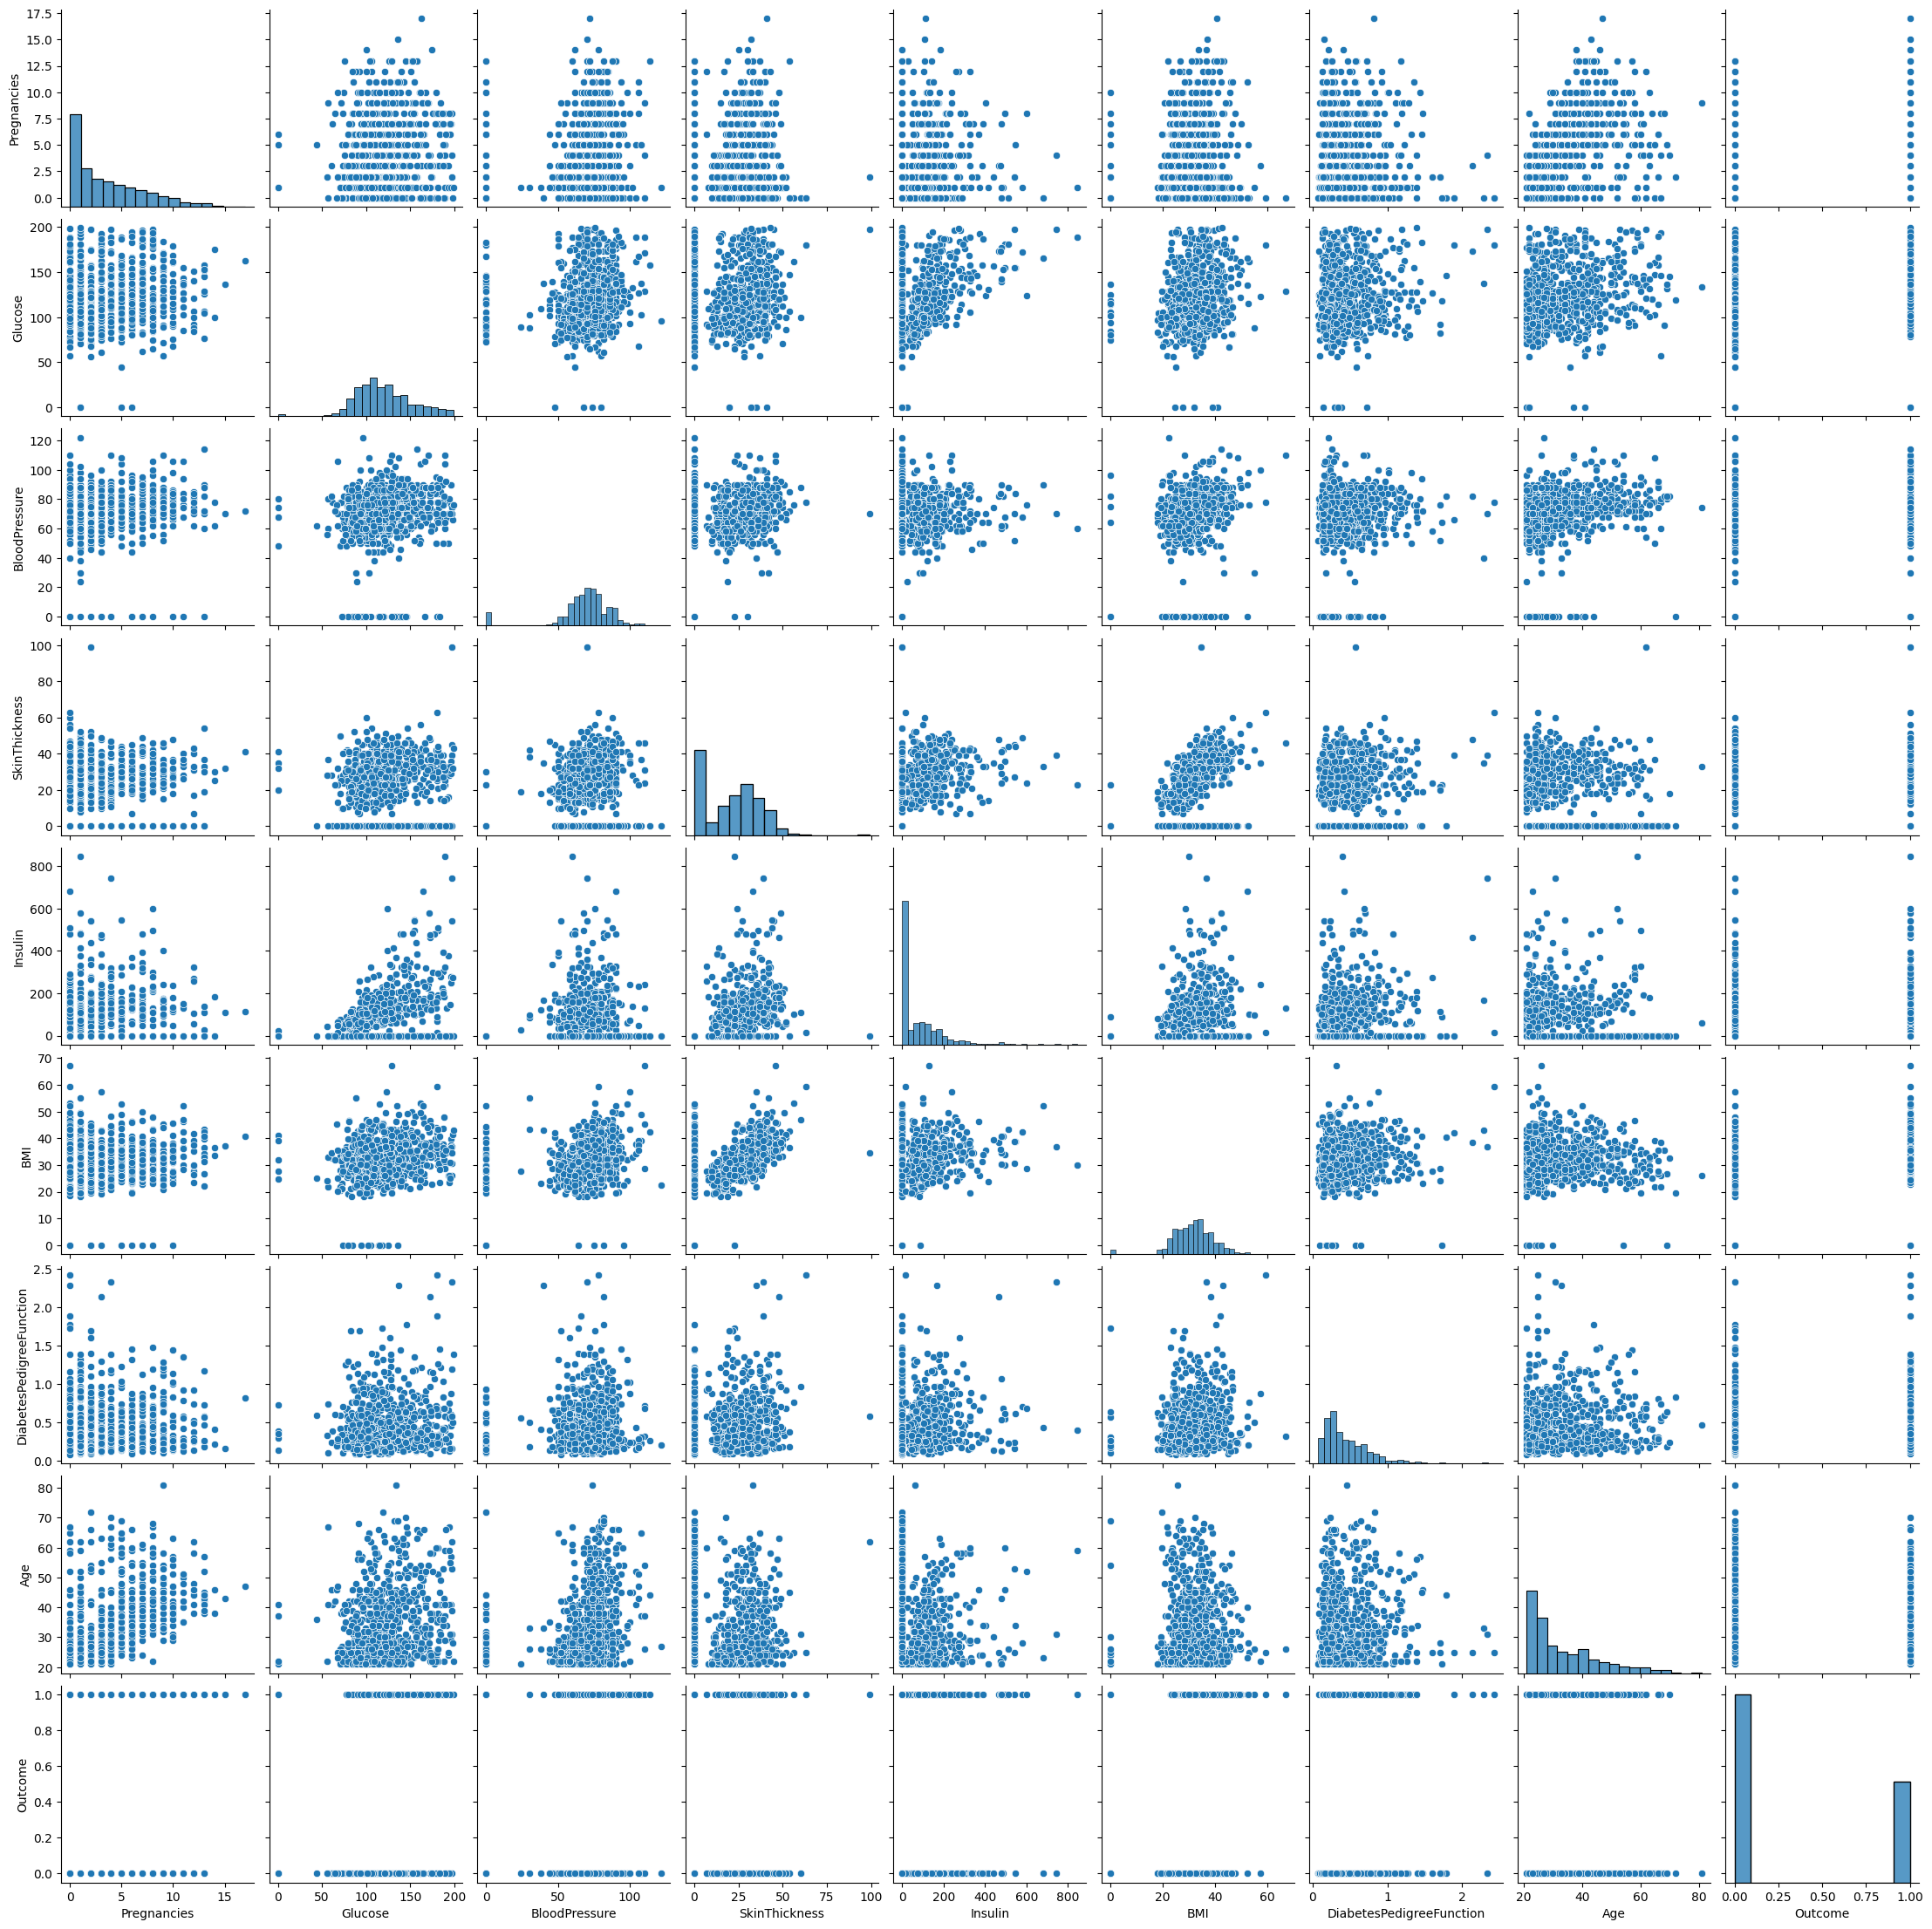

In [ ]:
sns.pairplot(data)

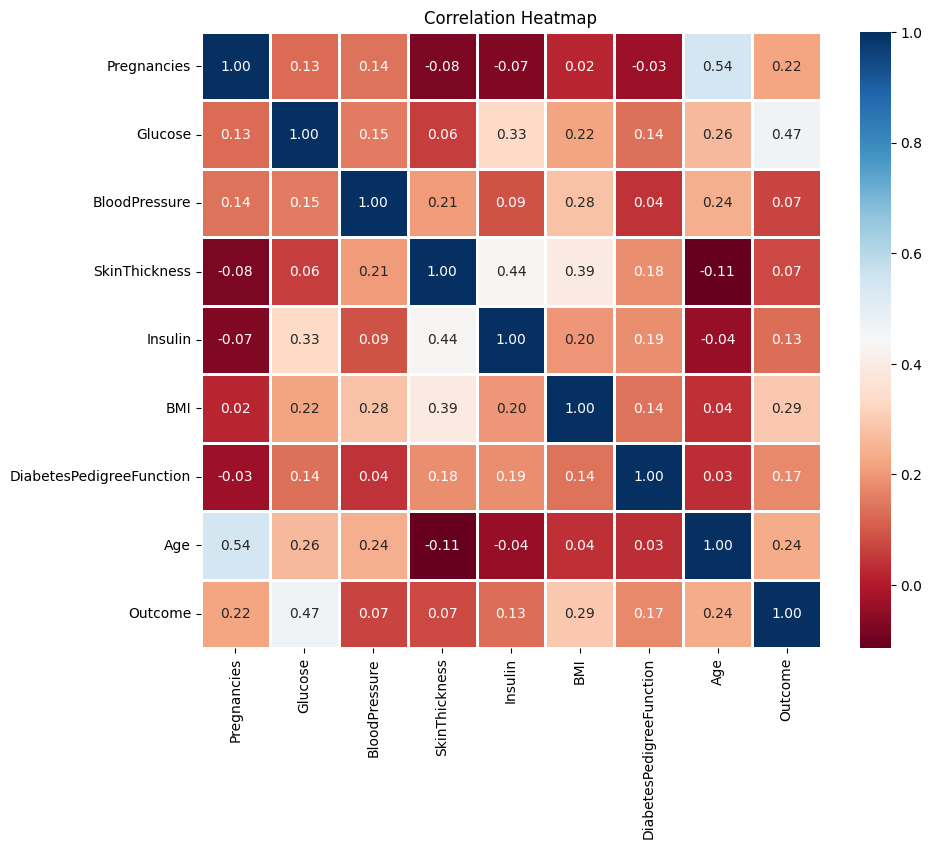

In [ ]:
# heatmap to see the correlation between features
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='RdBu', linewidths=2)

plt.title('Correlation Heatmap')
plt.show()

/tmp/ipython-input-1185842703.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x="Pregnancies", y="Age", data=data, palette='viridis')
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 42.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 44.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 41.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seabor

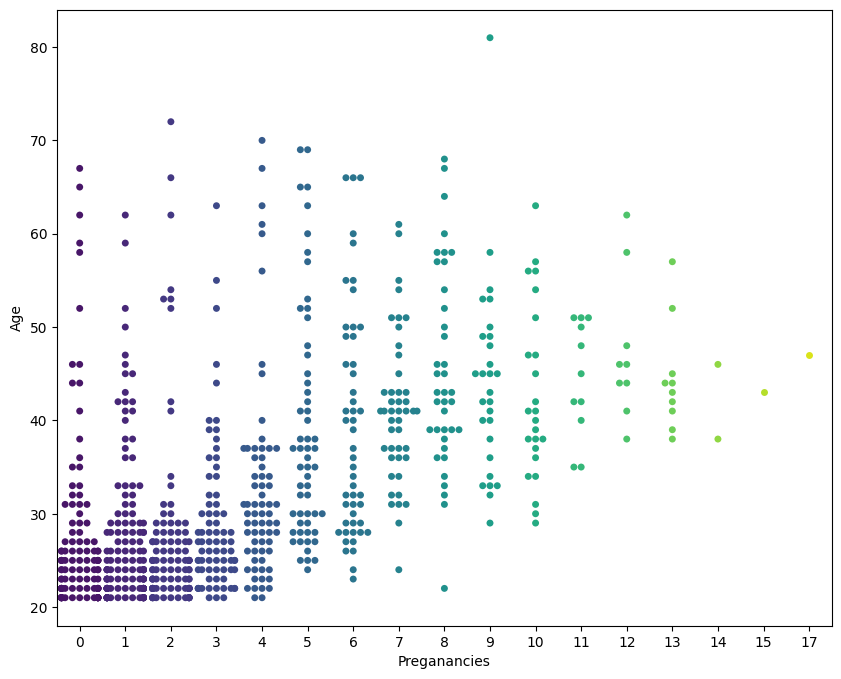

In [ ]:
plt.figure(figsize=(10, 8))

sns.swarmplot(x="Pregnancies", y="Age", data=data, palette='viridis')
plt.xlabel('Preganancies')
plt.ylabel('Age')
plt.show()

In [ ]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
cols = ['Pregnancies', 'Glucose', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']

In [ ]:
X = data[cols]        # independent
y = data['Outcome']   # dependent

In [ ]:
X.head()

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,0,33.6,0.627,50
1,1,85,0,26.6,0.351,31
2,8,183,0,23.3,0.672,32
3,1,89,94,28.1,0.167,21
4,0,137,168,43.1,2.288,33


# Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.37,
                                                    random_state=89,
                                                    shuffle=False,
                                                    )

In [ ]:
LR = LogisticRegression()

# fitting the model
LR.fit(X_train, y_train)
y_pred = LR.predict(X_test)

In [ ]:
from sklearn import metrics
acc = accuracy_score(y_test, y_pred) * 100
print(f"Logistics Regression model accuracy : {acc:.3f}%")

prec = precision_score(y_test, y_pred) * 100
print(f"Logistics Regression model precision : {prec:.3f}%")

print(metrics.classification_report(y_test, y_pred))

Logistics Regression model accuracy : 80.702%
Logistics Regression model precision : 73.333%
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       195
           1       0.73      0.61      0.67        90

    accuracy                           0.81       285
   macro avg       0.78      0.75      0.77       285
weighted avg       0.80      0.81      0.80       285



<Axes: >

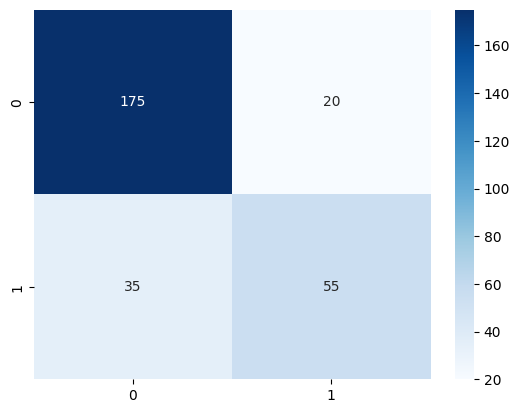

In [ ]:
# model evaluation using confusion matrix
from sklearn import metrics
CM = metrics.confusion_matrix(y_test, y_pred)

sns.heatmap(CM, annot=True, fmt='g', cmap='Blues')

In [ ]:
CM

array([[175,  20],
       [ 35,  55]])

## Conclusion

In this experiment, Logistic Regression was implemented for binary classification on two datasets. The model successfully demonstrated how the sigmoid function is used to estimate class probabilities and form a linear decision boundary.

Logistic Regression is a powerful and interpretable classification algorithm that:
- Uses the sigmoid function to model probabilities
- Performs well with proper regularization
- Provides strong baseline performance for classification tasks